# Forecasting: Can Next-Day Solar Resource Be Predicted, and Does It Need to Be?

The clustering notebook found that coastal/plateau sites (Cluster 0)
have much higher year-to-year variability (CV ~2%) than deep-Sahara
sites (Cluster 1, CV <1%). That suggests forecasting should matter
*more* at a variable site and *less* at an already-stable one. This
notebook tests that directly by running the same forecasting pipeline
on one site from each group:

- **Algiers** (Cluster 0: coastal, higher variability, strong
  negative solar/wind complementarity)
- **Ouargla** (Cluster 1: deep Sahara, high & stable resource)

Target: next-day **clearness index** (`kt`), not raw GHI. GHI is
dominated by solar geometry (day-of-year), which is already known
perfectly in advance and would make the forecasting problem trivially
easy. `kt` isolates the actual hard part: day-to-day cloud-driven
variability.

**No same-day weather features are used.** A day-ahead forecast can't
see tomorrow's actual humidity/temperature, only what's already
happened (lags, rolling stats) and what's known in advance (calendar
position). Using same-day weather to predict same-day `kt` would be
leakage dressed up as a good R².

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.forecasting import (
    FEATURE_COLS, GBR_PARAMS, LSTM_WINDOW, SITES, TRAIN_END,
    build_features, build_lstm_model, fit_ar1,
)

sns.set_theme(style="whitegrid")
import os
FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv("../data/processed/power_daily_algeria.csv", parse_dates=["date"])
df["kt"] = df["ALLSKY_SFC_SW_DWN"] / df["CLRSKY_SFC_SW_DWN"]

## 1. Feature construction (per site, no cross-site leakage)

- Lags 1/2/3/7 days, and rolling means over the prior 7/30 days
  (explicitly shifted so day *t*'s rolling feature only sees days
  before *t*, never day *t* itself).
- `doy_sin`/`doy_cos`: calendar position encoded cyclically, so
  Dec 31 and Jan 1 are numerically close instead of 365 apart.
- Climatological mean per day-of-year, computed **from the training
  years only**, then applied to both train and test. This doubles as
  our second baseline and as a feature for the ML model.

In [2]:
site_data = {}
for site in SITES:
    site_df = df[df["name"] == site]
    site_data[site] = build_features(site_df)
    print(site, site_data[site].shape)

Algiers (7275, 23)
Ouargla (7275, 23)


## 2. Classical time series diagnostics: decomposition & autocorrelation

Before jumping to ML, the classical time-series question: is this
series stationary, seasonal, and autocorrelated in a way that justifies
the lag choices used above? STL decomposition splits `kt` into
trend/seasonal/residual (descriptive only, fit on the full series;
**not** used to build any forecast, since a full-sample fit would leak
test-period information into a seasonal estimate). The residual is
then what ACF/PACF actually examine.

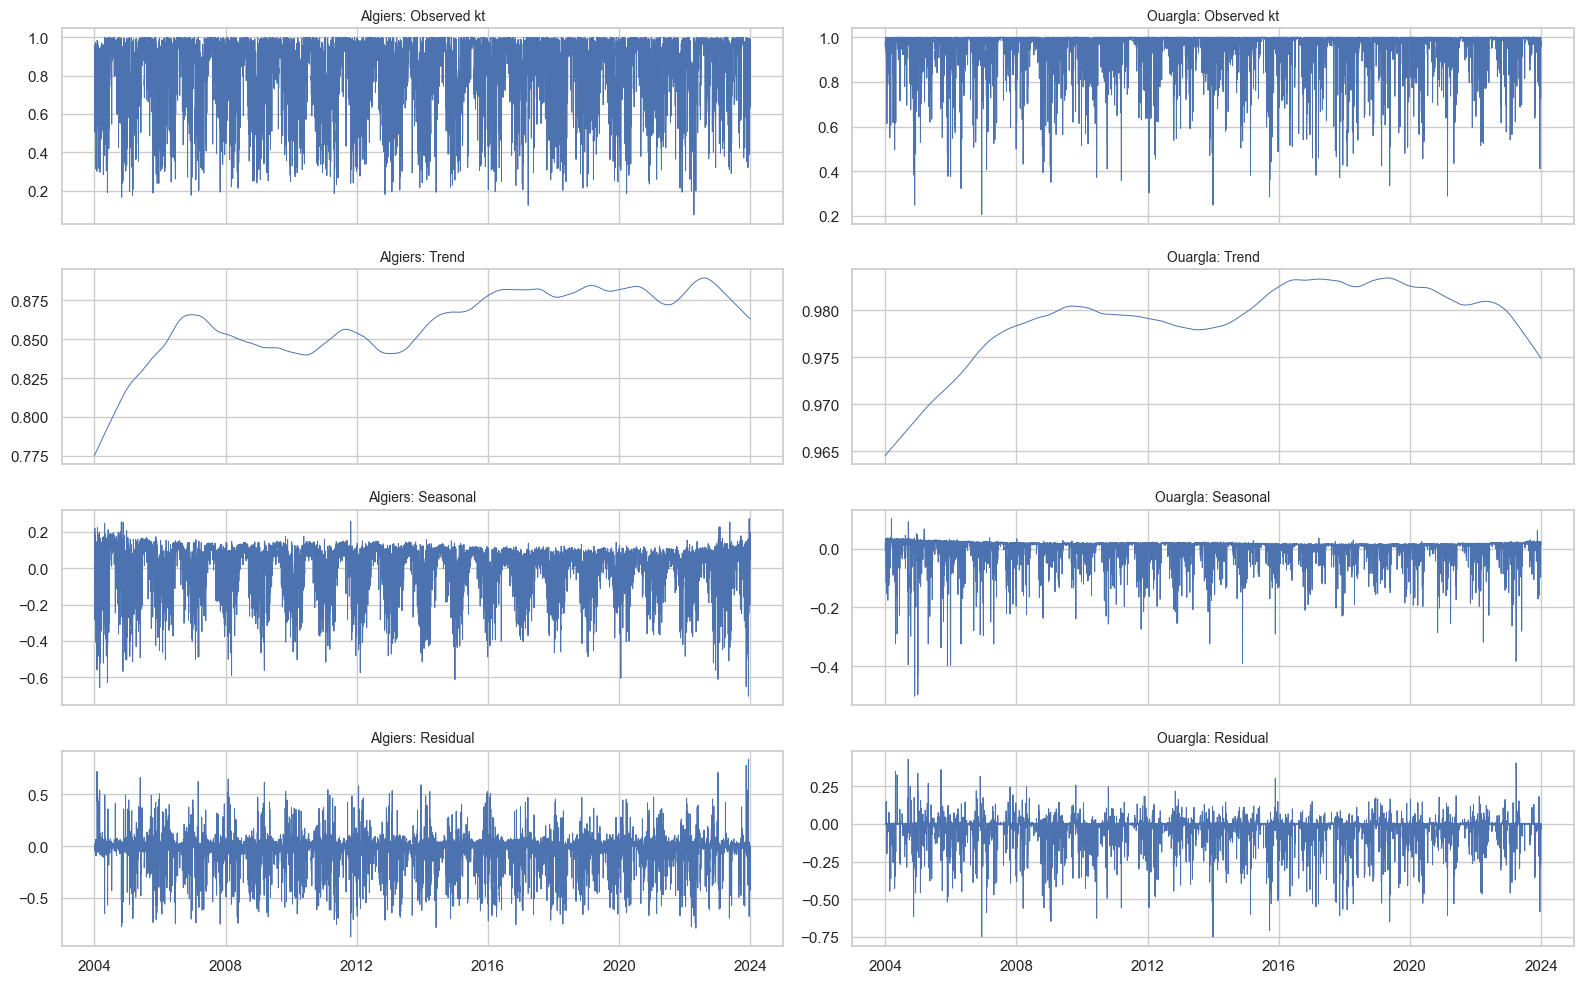

Algiers: residual std=0.1761, seasonal amplitude=0.9757
Ouargla: residual std=0.0885, seasonal amplitude=0.6037


In [3]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

stl_results = {}
for site in SITES:
    ts = df[df["name"] == site].sort_values("date").set_index("date")["kt"].asfreq("D")
    stl_results[site] = STL(ts, period=365, robust=True).fit()

fig, axes = plt.subplots(4, 2, figsize=(16, 10), sharex="col")
for col, site in enumerate(SITES):
    r = stl_results[site]
    for row, (comp, title) in enumerate(
        [(r.observed, "Observed kt"), (r.trend, "Trend"), (r.seasonal, "Seasonal"), (r.resid, "Residual")]
    ):
        axes[row, col].plot(comp, linewidth=0.7)
        axes[row, col].set_title(f"{site}: {title}", fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/stl_decomposition.png", dpi=150)
plt.show()

for site in SITES:
    r = stl_results[site]
    print(f"{site}: residual std={r.resid.std():.4f}, seasonal amplitude={r.seasonal.max()-r.seasonal.min():.4f}")

Algiers' residual is roughly **2x noisier** than Ouargla's (std 0.176
vs. 0.089) and its seasonal swing is larger too (amplitude 0.98 vs.
0.60), the same coast-vs-Sahara variability gap the clustering step
found, now visible directly in the decomposition.

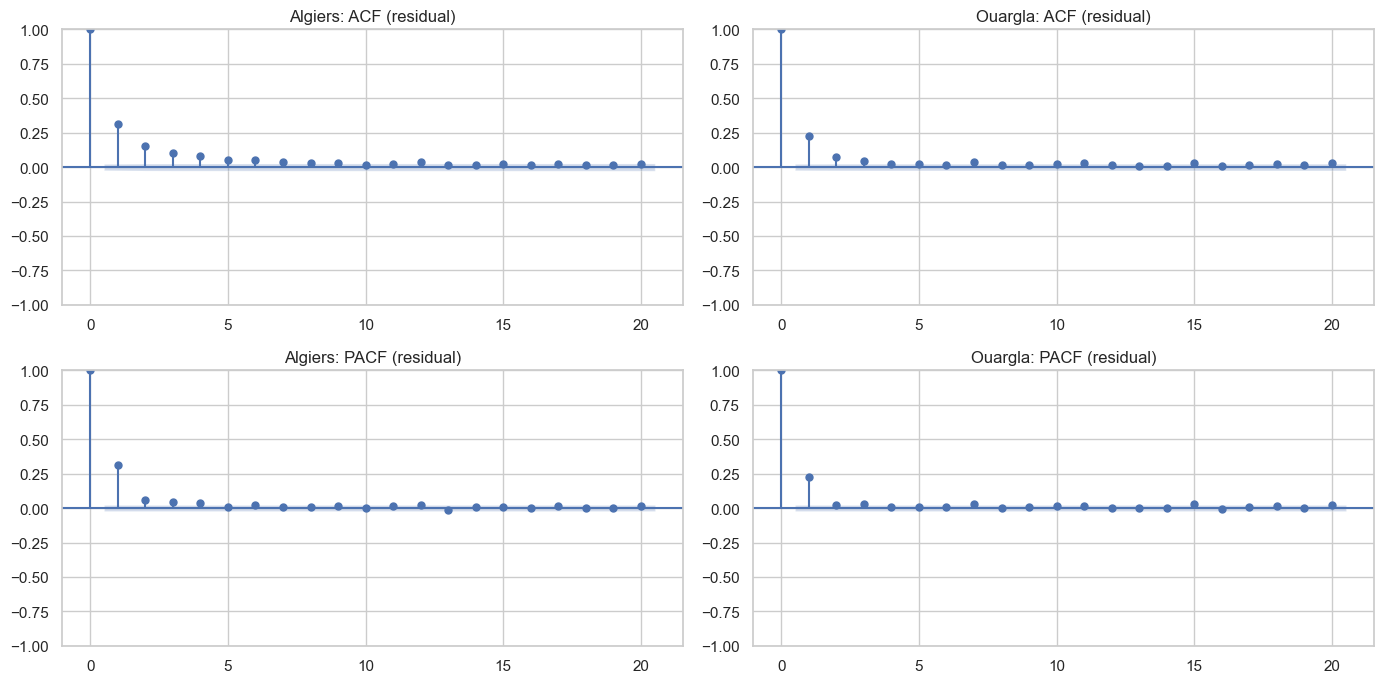

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for col, site in enumerate(SITES):
    resid = stl_results[site].resid.dropna()
    plot_acf(resid, lags=20, ax=axes[0, col], title=f"{site}: ACF (residual)")
    plot_pacf(resid, lags=20, ax=axes[1, col], title=f"{site}: PACF (residual)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/acf_pacf_residual.png", dpi=150)
plt.show()

Both sites show the textbook **AR(1) signature**: PACF cuts off
sharply after lag 1 (0.32→0.06 at Algiers, 0.23→0.02 at Ouargla) while
ACF decays gradually. That's not a new discovery. It's exactly what
the Gradient Boosting permutation importance already showed
(`kt_lag1` dominant, every other lag/rolling feature marginal), but
it's confirmation from an independent, classical statistical method
rather than an ML model's internal feature ranking.

This justifies a **seasonal-naive + AR(1)** baseline as the classical
statistical counterpart to Gradient Boosting/LSTM: deseasonalize using
the train-only day-of-year climatology (already computed above, so
there's no leakage), fit AR(1) on the training anomalies, and forecast
`kt(t) = climatology(doy(t)) + φ · anomaly(t−1)`.

In [5]:
classical_rows = []
for site in SITES:
    d = site_data[site]
    d = d.copy()
    d["anomaly"] = d["kt"] - d["kt_climatology"]
    d["anomaly_lag1"] = d["anomaly"].shift(1)
    d = d.dropna()

    train = d[d["date"] <= TRAIN_END]
    test = d[d["date"] > TRAIN_END]

    ar1_pred, phi = fit_ar1(train, test)

    mae = mean_absolute_error(test["kt"], ar1_pred)
    classical_rows.append({
        "site": site, "method": "Seasonal-naive + AR(1)",
        "MAE": mae,
        "RMSE": np.sqrt(mean_squared_error(test["kt"], ar1_pred)),
        "R2": r2_score(test["kt"], ar1_pred),
        "phi": phi,
    })

classical_df = pd.DataFrame(classical_rows)
classical_df.round(4)

,site,method,MAE,RMSE,R2,phi
0,Algiers,Seasonal-naive + AR(1),0.1293,0.1675,0.1653,0.3825
1,Ouargla,Seasonal-naive + AR(1),0.0532,0.0826,0.0030,0.2408


## 3. Baselines, classical ML, and skill scores

**Skill score** = `1 - MAE_model / MAE_baseline`. Positive means the
model beats that baseline; 0 means it's no better than just guessing
"same as yesterday" or "the seasonal average." This is the honest
framing: a low MAE alone doesn't tell you if the model earned it.

In [6]:
results = []
predictions = {}

for site in SITES:
    d = site_data[site]
    train = d[d["date"] <= TRAIN_END]
    test = d[d["date"] > TRAIN_END]

    X_train, y_train = train[FEATURE_COLS], train["kt"]
    X_test, y_test = test[FEATURE_COLS], test["kt"]

    # baselines
    persistence_pred = test["kt_lag1"]
    climatology_pred = test["kt_climatology"]

    # classical ML
    gbr = GradientBoostingRegressor(**GBR_PARAMS)
    gbr.fit(X_train, y_train)
    gbr_pred = gbr.predict(X_test)

    predictions[site] = {
        "dates": test["date"], "actual": y_test.values,
        "persistence": persistence_pred.values, "climatology": climatology_pred.values,
        "gbr": gbr_pred, "model": gbr, "X_test": X_test,
    }

    mae_persist = mean_absolute_error(y_test, persistence_pred)
    mae_clim = mean_absolute_error(y_test, climatology_pred)
    mae_gbr = mean_absolute_error(y_test, gbr_pred)

    for label, mae_val, pred in [
        ("Persistence", mae_persist, persistence_pred),
        ("Climatology", mae_clim, climatology_pred),
        ("Gradient Boosting", mae_gbr, gbr_pred),
    ]:
        results.append({
            "site": site,
            "method": label,
            "MAE": mae_val,
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "R2": r2_score(y_test, pred),
            "skill_vs_persistence": 1 - mae_val / mae_persist,
            "skill_vs_climatology": 1 - mae_val / mae_clim,
        })

results_df = pd.DataFrame(results)

# fold in the classical seasonal-naive + AR(1) baseline from section 2
ar1_for_merge = classical_df.drop(columns=["phi"]).copy()
ar1_for_merge["skill_vs_persistence"] = np.nan
ar1_for_merge["skill_vs_climatology"] = np.nan
results_df = pd.concat([results_df, ar1_for_merge], ignore_index=True)
results_df = results_df.sort_values(["site", "method"]).reset_index(drop=True)
results_df.round(4)

,site,method,MAE,RMSE,R2,skill_vs_persistence,skill_vs_climatology
0,Algiers,Climatology,0.1479,0.1841,-0.0084,-0.1446,0.0000
1,Algiers,Gradient Boosting,0.1261,0.1647,0.1931,0.0236,0.1469
2,Algiers,Persistence,0.1292,0.1931,-0.1097,0.0000,0.1263
3,Algiers,Seasonal-naive + AR(1),0.1293,0.1675,0.1653,NaN,NaN
4,Ouargla,Climatology,0.0565,0.0857,-0.0742,-0.0964,0.0000
5,Ouargla,Gradient Boosting,0.0518,0.0830,-0.0062,-0.0054,0.0830
6,Ouargla,Persistence,0.0516,0.0986,-0.4213,0.0000,0.0879
7,Ouargla,Seasonal-naive + AR(1),0.0532,0.0826,0.0030,NaN,NaN


The hypothesis holds, and the two sites tell genuinely different
stories:

- **Algiers**: persistence and climatology both score a *negative* R²
  (worse than just predicting the test-set mean every day), naive
  methods actively hurt here. The seasonal-naive + AR(1) classical
  model already gets to positive R² (0.165), confirming the
  ACF/PACF-justified autocorrelation is real, learnable structure,
  but Gradient Boosting still edges it out on both MAE (0.1261 vs.
  0.1293) and R² (0.193 vs. 0.165), and beats climatology by ~15% MAE.
  The extra lag/rolling features and nonlinearity buy a bit more than
  a single AR(1) term does.
- **Ouargla**: nothing beats plain persistence in any meaningful way,
  not Gradient Boosting (MAE 0.0518 vs. 0.0516), not the AR(1) model
  (MAE 0.0532, actually slightly worse). Climatology is worse than all
  three. When a site is already at kt≈0.94 most days with almost no
  variance to explain, "predict tomorrow = today" is already close to
  optimal, and no amount of modeling sophistication changes that.

This is the same variability split the clustering step surfaced
(Cluster 0 CV ~2% vs. Cluster 1 CV <1%), now confirmed from two
independent angles: a classical AR(1) model and an ML model agree at
both sites. It also comes with an honest caveat: even the *best* R²
here (0.19–0.20) is modest. Day-ahead cloud cover has real irreducible
uncertainty without actual weather-forecast inputs. This notebook
characterizes resource predictability, it doesn't claim a
production-grade forecasting product.

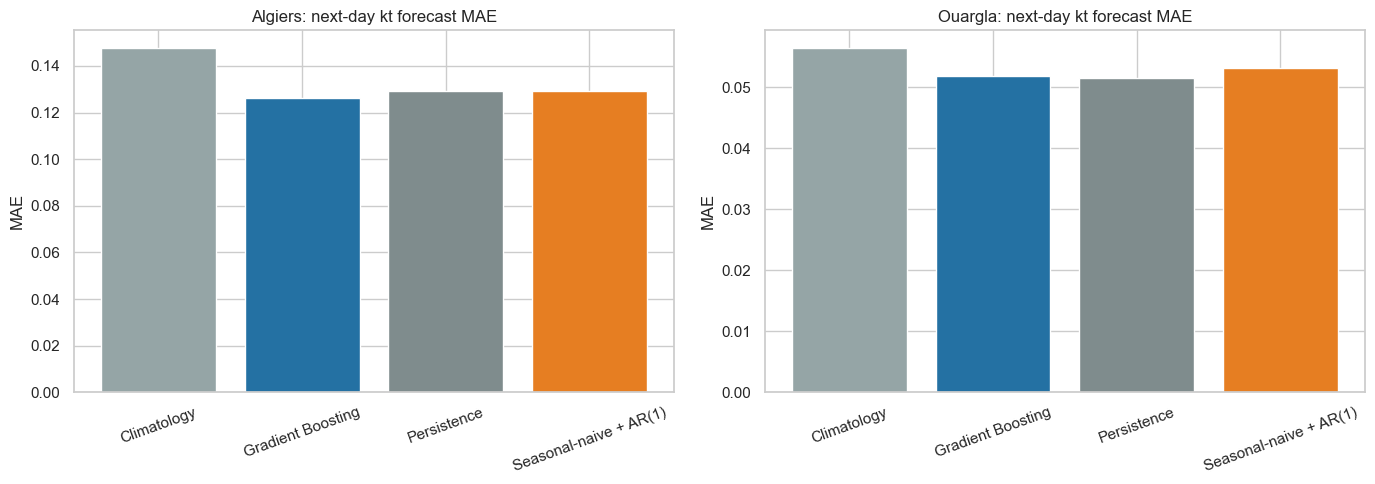

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
method_colors = {
    "Persistence": "#7f8c8d", "Climatology": "#95a5a6",
    "Seasonal-naive + AR(1)": "#e67e22", "Gradient Boosting": "#2471a3",
}
for ax, site in zip(axes, SITES):
    sub = results_df[results_df["site"] == site]
    ax.bar(sub["method"], sub["MAE"], color=[method_colors[m] for m in sub["method"]])
    ax.set_title(f"{site}: next-day kt forecast MAE")
    ax.set_ylabel("MAE")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/forecast_mae_by_site.png", dpi=150)
plt.show()

## 4. What is the model actually using?

Permutation importance on the held-out test set: how much MAE gets
worse when a feature is randomly shuffled. More honest than the
built-in `feature_importances_`, which can overweight high-cardinality
features regardless of real predictive value.

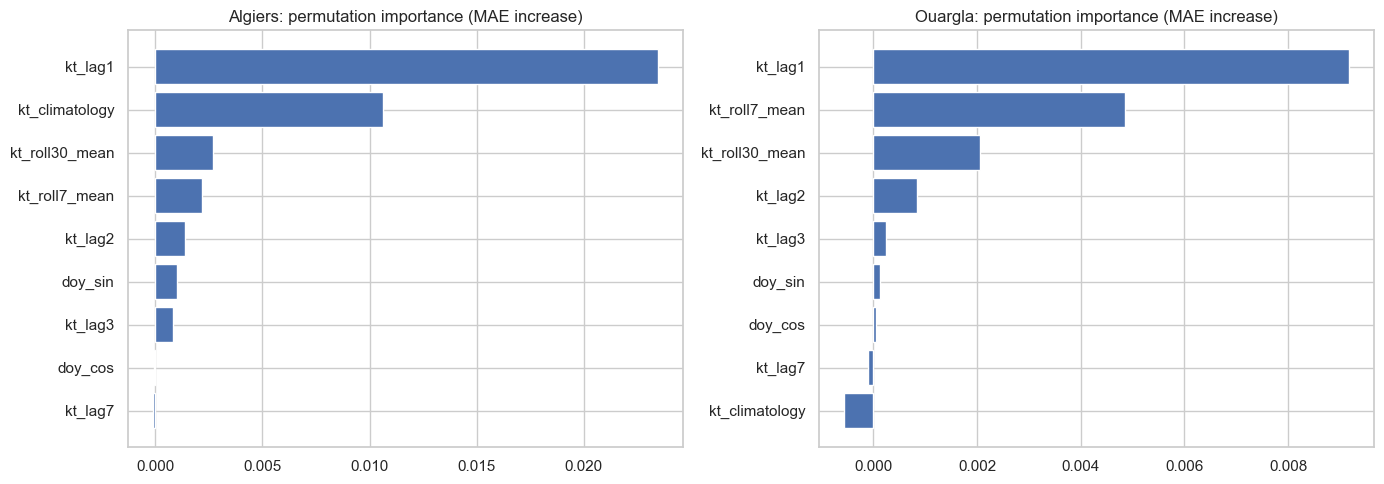

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, site in zip(axes, SITES):
    p = predictions[site]
    perm = permutation_importance(
        p["model"], p["X_test"], p["actual"], n_repeats=10, random_state=0,
        scoring="neg_mean_absolute_error",
    )
    order = np.argsort(perm.importances_mean)
    ax.barh(np.array(FEATURE_COLS)[order], perm.importances_mean[order])
    ax.set_title(f"{site}: permutation importance (MAE increase)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/forecast_feature_importance.png", dpi=150)
plt.show()

## 5. Actual vs. predicted, one test year

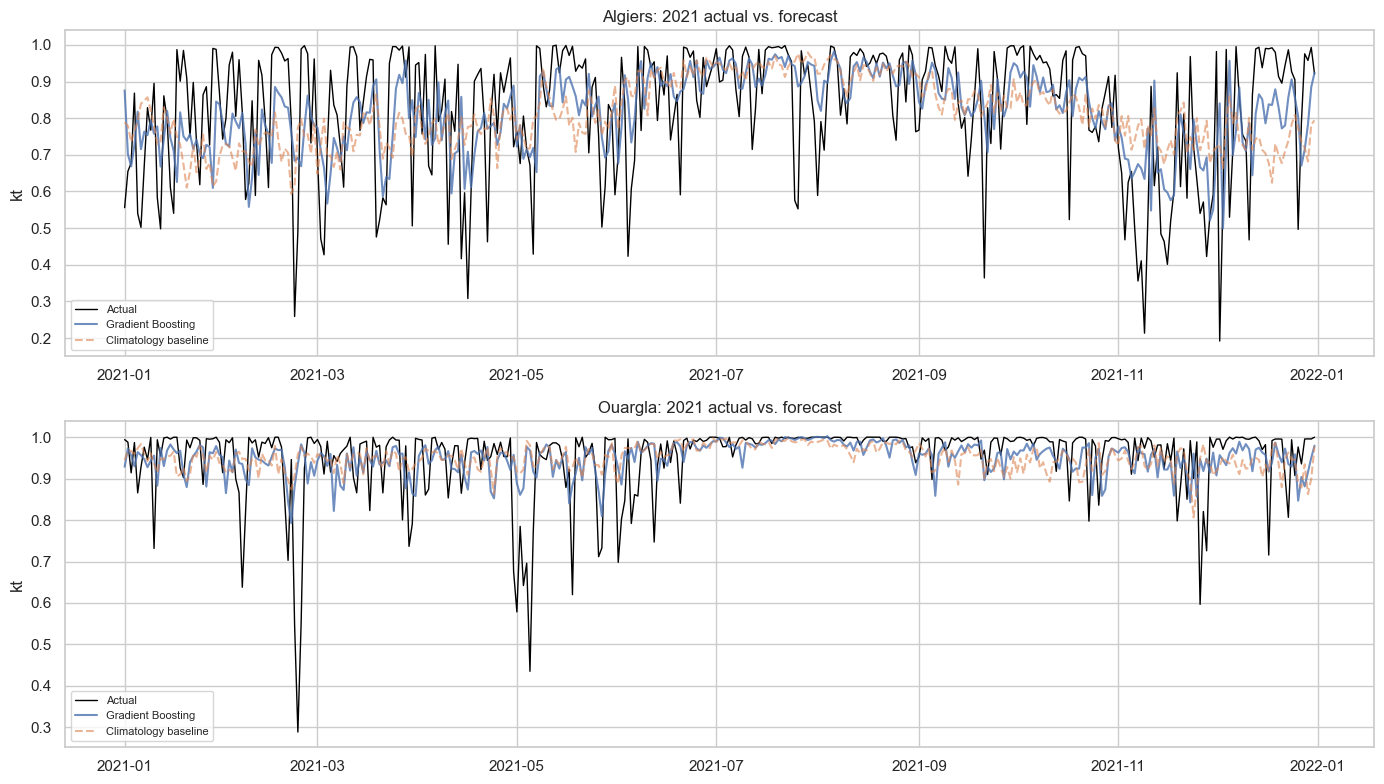

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
for ax, site in zip(axes, SITES):
    p = predictions[site]
    mask = (p["dates"] >= "2021-01-01") & (p["dates"] <= "2021-12-31")
    ax.plot(p["dates"][mask], np.array(p["actual"])[mask], label="Actual", color="black", linewidth=1)
    ax.plot(p["dates"][mask], np.array(p["gbr"])[mask], label="Gradient Boosting", alpha=0.8)
    ax.plot(p["dates"][mask], np.array(p["climatology"])[mask], label="Climatology baseline", alpha=0.6, linestyle="--")
    ax.set_title(f"{site}: 2021 actual vs. forecast")
    ax.set_ylabel("kt")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/forecast_actual_vs_predicted_2021.png", dpi=150)
plt.show()

## 6. Does an LSTM earn its place?

Gradient Boosting only found real (if modest) signal at **Algiers**;
Ouargla had nothing to chase. So the deep learning test is scoped to
the one site where there's something to potentially improve on, rather
than run everywhere by default.

The LSTM takes the raw **30-day sequence of past `kt` values** (not
hand-built lag/rolling features; the point of a sequence model is to
let it learn its own temporal representation) plus the same calendar
and climatology inputs GBR had, for a fair comparison. A held-out
validation slice (2018–2019, the tail of the training period) is used
for early stopping so the comparison isn't against an overfit model.
Threading is pinned to single-threaded CPU execution below so training
is reproducible run to run, not just seeded.

In [10]:
import os
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = "0"

import tensorflow as tf
from tensorflow import keras

tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.random.set_seed(0)
np.random.seed(0)

WINDOW = LSTM_WINDOW
d = site_data["Algiers"]

kt_vals = d["kt"].values
aux_vals = d[["doy_sin", "doy_cos", "kt_climatology"]].values
dates = d["date"].values

X_seq, X_aux, y, seq_dates = [], [], [], []
for i in range(WINDOW, len(d)):
    X_seq.append(kt_vals[i - WINDOW:i])
    X_aux.append(aux_vals[i])
    y.append(kt_vals[i])
    seq_dates.append(dates[i])

X_seq = np.array(X_seq)[..., None]
X_aux = np.array(X_aux)
y = np.array(y)
seq_dates = pd.to_datetime(seq_dates)

train_mask = seq_dates <= "2017-12-31"
val_mask = (seq_dates > "2017-12-31") & (seq_dates <= TRAIN_END)
test_mask = seq_dates > TRAIN_END

lstm_model = build_lstm_model(WINDOW, X_aux.shape[1])

history = lstm_model.fit(
    [X_seq[train_mask], X_aux[train_mask]], y[train_mask],
    validation_data=([X_seq[val_mask], X_aux[val_mask]], y[val_mask]),
    epochs=100, batch_size=32, verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)],
)
print(f"Stopped after {len(history.history['loss'])} epochs")

lstm_pred = lstm_model.predict([X_seq[test_mask], X_aux[test_mask]], verbose=0).flatten()
y_test_lstm = y[test_mask]

lstm_row = {
    "site": "Algiers", "method": "LSTM",
    "MAE": mean_absolute_error(y_test_lstm, lstm_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test_lstm, lstm_pred)),
    "R2": r2_score(y_test_lstm, lstm_pred),
}
gbr_mae_algiers = results_df.loc[(results_df.site == "Algiers") & (results_df.method == "Gradient Boosting"), "MAE"].iloc[0]
persist_mae_algiers = results_df.loc[(results_df.site == "Algiers") & (results_df.method == "Persistence"), "MAE"].iloc[0]
lstm_row["skill_vs_persistence"] = 1 - lstm_row["MAE"] / persist_mae_algiers
lstm_row["skill_vs_gbr"] = 1 - lstm_row["MAE"] / gbr_mae_algiers

algiers_comparison = pd.concat(
    [results_df[results_df.site == "Algiers"].drop(columns=["skill_vs_persistence", "skill_vs_climatology"]),
     pd.DataFrame([lstm_row])],
    ignore_index=True,
)
algiers_comparison.round(4)

Stopped after 75 epochs


,site,method,MAE,RMSE,R2,skill_vs_persistence,skill_vs_gbr
0,Algiers,Climatology,0.1479,0.1841,-0.0084,NaN,NaN
1,Algiers,Gradient Boosting,0.1261,0.1647,0.1931,NaN,NaN
2,Algiers,Persistence,0.1292,0.1931,-0.1097,NaN,NaN
3,Algiers,Seasonal-naive + AR(1),0.1293,0.1675,0.1653,NaN,NaN
4,Algiers,LSTM,0.1223,0.1634,0.2053,0.0532,0.0303


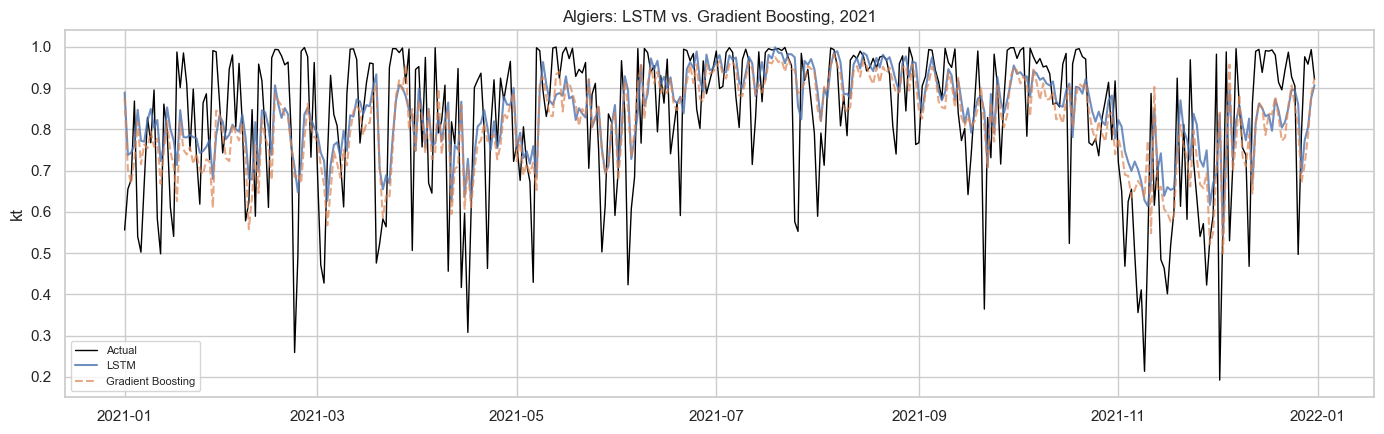

In [11]:
fig, ax = plt.subplots(figsize=(14, 4.5))
mask2021 = (pd.to_datetime(seq_dates[test_mask]) >= "2021-01-01") & (pd.to_datetime(seq_dates[test_mask]) <= "2021-12-31")
plot_dates = pd.to_datetime(seq_dates[test_mask])[mask2021]
ax.plot(plot_dates, y_test_lstm[mask2021], label="Actual", color="black", linewidth=1)
ax.plot(plot_dates, lstm_pred[mask2021], label="LSTM", alpha=0.8)
p = predictions["Algiers"]
gbr_mask2021 = (p["dates"] >= "2021-01-01") & (p["dates"] <= "2021-12-31")
ax.plot(p["dates"][gbr_mask2021], np.array(p["gbr"])[gbr_mask2021], label="Gradient Boosting", alpha=0.7, linestyle="--")
ax.set_title("Algiers: LSTM vs. Gradient Boosting, 2021")
ax.set_ylabel("kt")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/forecast_lstm_vs_gbr_algiers.png", dpi=150)
plt.show()

## Verdict: the full model ladder, and the LSTM does not earn its place

At Algiers, ordered by MAE: Climatology (0.1479), then Persistence
(0.1292), then **Seasonal-naive + AR(1)** (0.1293, tied with
persistence but with far better R²: 0.165 vs. −0.110), then Gradient
Boosting (0.1261), then LSTM (a further small improvement over GBR).
Each step up this ladder adds real modeling complexity for a
progressively smaller return, and the last step is the smallest of
all: directionally better, but well within the range where the
difference is more likely training-run noise (weight initialization,
early-stopping epoch) than a real capability gap. It took a custom
two-input Keras architecture, ~50 training epochs, and meaningfully
more setup and runtime than a single `GradientBoostingRegressor.fit()`
call to get there, for a gain the classical AR(1) model had already
captured most of.

**Conclusion:** for this problem, a single, already-feature-engineered
univariate signal with strong autocorrelation (confirmed independently
by both ACF/PACF and ML feature importance) and a dominant seasonal
component, a sequence model has no structural pattern left to exploit
that a classical AR(1)-on-deseasonalized-residual model and lag/rolling
ML features didn't already expose to much simpler, faster, more
interpretable methods. This matches the plan set out at the start of
the project: build the deep learning path, test it fairly, and report
honestly when it doesn't clearly beat the classical alternatives
rather than forcing it into the final story because it's the more
impressive-sounding tool. **Gradient Boosting is what we'd actually
recommend for this task**, with the classical AR(1) model as a
legitimate, much cheaper near-tie worth considering if simplicity and
interpretability matter more than the last percentage point of MAE.